## 1.INTRODUCTION :

  - La fraude par carte bancaire représente aujourd’hui un enjeu majeur pour les institutions financières, en raison des pertes économiques importantes et des risques pour les clients.
     Avec l’augmentation du volume des transactions électroniques, il devient difficile de détecter manuellement les comportements frauduleux.
  Le problème traité dans ce projet consiste à détecter automatiquement les transactions frauduleuses à partir de données historiques, en utilisant des techniques de deep learning. L’intérêt principal du sujet réside dans le fait que les données sont fortement déséquilibrées, ce qui rend la détection de la fraude particulièrement complexe et nécessite des méthodes spécifiques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Dense,Flatten
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.utils import class_weight
from keras.layers import Dropout, BatchNormalization
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

## 2.PRÉSENTATION DU DATASET 

### 2.1 Source et Contexte

Nous avons utilisé le Credit Card Fraud Detection Dataset, disponible sur Kaggle. 
Il s'agit d'un dataset de référence dans le domaine de la détection de fraudes, largement utilisé par la communauté scientifique et les professionnels du secteur bancaire. Ce dataset contient des transactions réelles de cartes de crédit effectuées par des clients européens en septembre 2013.

In [2]:
#chargement de datasets:
df = pd.read_csv('creditcard.csv')
df.head()




,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2.2 Structure des Données

Notre dataset comprend 284,807 transactions au total, avec 30 variables explicatives :
* 28 variables nommées V1 à V28, qui sont le résultat d'une transformation PCA - c'est-à-dire qu'elles ont été anonymisées pour des raisons de confidentialité
* La variable Time, qui représente le temps écoulé entre chaque transaction et la première transaction du dataset
* La variable Amount, qui indique le montant de la transaction
Et enfin, notre variable cible "Class" : 0 pour les transactions légitimes, et 1 pour les transactions frauduleuses.

### 2.3 Le Défi du Déséquilibre Extrême

Un point crucial à souligner : nous sommes face à un déséquilibre extrême des classes. Sur les 284,807 transactions :

284,315 sont légitimes, soit 99.83% Seulement 492 sont frauduleuses, soit 0.17%

Ce déséquilibre représente l'un des principaux défis de notre projet. Dans la réalité bancaire, c'est effectivement cette proportion que l'on observe : les fraudes sont rares mais doivent être détectées avec précision.


### 2.4 Nettoyage et Division du dataset

Concernant le prétraitement des données, nous avons procédé en deux étapes :
Premièrement, le nettoyage :

Nous avons identifié et supprimé les lignes dupliquées
Le dataset est passé de 284,807 à environ 283,700 lignes après nettoyage

In [3]:
#supression des lignes dupliquées
df_cleaned=df.drop_duplicates()

In [4]:
print(f"lignes avant nettoyage:{df.shape[0]}")
print(f"lignes aprés nettoyage:{df_cleaned.shape[0]}")

lignes avant nettoyage:284807
lignes aprés nettoyage:283726


Deuxièmement Nous avons séparé nos données en deux ensembles 70% pour l'entraînement, soit environ 199,364 transactions 30% pour le test, soit environ 85,443 transactions Cette division permet d'évaluer objectivement les performances de notre modèle sur des données qu'il n'a jamais vues

In [5]:
# Dévision des données :
X=df.drop('Class',axis=1).values
y=df['Class'].values


In [6]:
#Diviser les données en ensembles d'entrainement et de test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=101)

### 2.5 Équilibrage avec SMOTE

Pour résoudre le déséquilibre, nous avons utilisé SMOTE (Synthetic Minority Over-sampling Technique) :

In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

SMOTE génère des exemples synthétiques de fraudes en interpolant entre les exemples existants, ce qui permet au modèle d'apprendre sans biais vers la classe majoritaire.

In [8]:
print("Avant SMOTE :", np.bincount(y_train))
print("Après SMOTE :", np.bincount(y_train_smote))

Avant SMOTE : [199016    348]
Après SMOTE : [199016 199016]


### 2.6 Pondération des classes (Class Weighting)

Nous avons utilisé une pondération des classes afin de donner plus d’importance à la classe fraude lors de l’apprentissage, ce qui permet d’améliorer sa détection dans un contexte de données déséquilibrées.

In [9]:
from sklearn.utils import class_weight
import numpy as np

# Calcul automatique des poids des classes
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_smote), y=y_train_smote)
class_weight_dict = dict(enumerate(class_weights))
print("Poids des classes (0: non-fraude, 1: fraude):", class_weight_dict)

Poids des classes (0: non-fraude, 1: fraude): {0: np.float64(1.0), 1: np.float64(1.0)}


### 2.7 Normalisation

Nous avons appliqué un MinMaxScaler sur l'ensemble des variables Cela permet de ramener toutes les valeurs dans une échelle commune entre 0 et 1 Les variables V1 à V28 étaient déjà normalisées grâce à la transformation PCA

In [10]:
# Normalisation:
min_max_scaler=MinMaxScaler()
X_train_minmax=min_max_scaler.fit_transform(X_train_smote)
X_test_minmax=min_max_scaler.transform(X_test)

## 3.MÉTHODOLOGIE & ARCHITECTURE DU MODÈLE

### 3.1 Choix du Modèle

Pour ce projet de détection de fraude, nous avons choisi d’utiliser un réseau de neurones profond (Deep Neural Network) à architecture séquentielle.

Ce choix est principalement motivé par la nature du dataset. Les variables V1 à V28 proviennent d’une Analyse en Composantes Principales (PCA). Elles sont donc déjà décorrélées, mais cela ne signifie pas qu’il n’existe pas de relations non linéaires complexes entre elles. Un modèle linéaire simple ne serait donc pas suffisant.

Nous avons étudié plusieurs alternatives :

La régression logistique, bien qu’interprétable et rapide, reste limitée aux relations linéaires.

Les Random Forests, robustes face au déséquilibre des classes, donnent généralement de moins bonnes performances sur des données déjà transformées par PCA.

Les modèles séquentiels (LSTM, RNN) introduisent une dimension temporelle intéressante, mais leur coût computationnel n’est pas justifié ici, car les transactions sont traitées de manière indépendante.

Le Deep Neural Network représente donc un excellent compromis : il permet de capturer des patterns complexes, tout en restant simple à entraîner et efficace.

### 3.2 Architecture Globale

Notre modèle suit une architecture séquentielle simple et efficace :

Entrée : 30 features (V1–V28, Time, Amount).

Couche Dense 1 : 64 neurones, activation ReLU pour extraire des features complexes.

Batch Normalization : stabilise l’apprentissage et accélère la convergence.

Dropout 0.3 : régularisation pour limiter le surapprentissage.

Couche Dense 2 : 32 neurones, ReLU + Dropout 0.3.

Couche Dense 3 : 16 neurones, ReLU.

Sortie : 1 neurone, sigmoid pour prédire une probabilité de fraude.

Cette architecture progressive permet d’apprendre des représentations hiérarchiques, évitant le vanishing gradient et stabilisant l’apprentissage grâce au BatchNorm et Dropout.

In [11]:
#Création du model
n_features = X_train_minmax.shape[1]
model = Sequential()
model.add(Input(shape=(n_features,)))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

### 3.3 Fonctions de perte, Optimiseur et Hyperparamètres

Fonction de perte : binary_crossentropy (standard pour classification binaire).

Optimiseur : Adam avec learning rate  0.0001, combinant les avantages du momentum et de RMSprop.

Batch size : 2048 → compromis entre stabilité du gradient et mémoire GPU.

Epochs : 15, déterminées empiriquement.

Class weights : pour gérer le déséquilibre extrême (99,83% légitimes, 0,17% fraudes)

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

In [13]:

history = model.fit(
    X_train_minmax, 
    y_train_smote, 
    batch_size=2048,  
    epochs=15, 
    verbose=2,
    validation_data=(X_test_minmax, y_test), 
    class_weight=class_weight_dict
)

Epoch 1/15
195/195 - 8s - 42ms/step - accuracy: 0.7299 - loss: 0.5521 - val_accuracy: 0.9349 - val_loss: 0.5755
Epoch 2/15
195/195 - 2s - 12ms/step - accuracy: 0.9054 - loss: 0.2782 - val_accuracy: 0.9829 - val_loss: 0.3251
Epoch 3/15
195/195 - 6s - 28ms/step - accuracy: 0.9353 - loss: 0.1975 - val_accuracy: 0.9890 - val_loss: 0.1284
Epoch 4/15
195/195 - 3s - 13ms/step - accuracy: 0.9482 - loss: 0.1575 - val_accuracy: 0.9887 - val_loss: 0.0691
Epoch 5/15
195/195 - 3s - 15ms/step - accuracy: 0.9553 - loss: 0.1350 - val_accuracy: 0.9878 - val_loss: 0.0579
Epoch 6/15
195/195 - 2s - 11ms/step - accuracy: 0.9596 - loss: 0.1203 - val_accuracy: 0.9882 - val_loss: 0.0485
Epoch 7/15
195/195 - 3s - 14ms/step - accuracy: 0.9625 - loss: 0.1108 - val_accuracy: 0.9866 - val_loss: 0.0524
Epoch 8/15
195/195 - 5s - 26ms/step - accuracy: 0.9651 - loss: 0.1028 - val_accuracy: 0.9894 - val_loss: 0.0392
Epoch 9/15
195/195 - 2s - 11ms/step - accuracy: 0.9666 - loss: 0.0980 - val_accuracy: 0.9900 - val_loss:

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,341 (56.02 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 9,476 (37.02 KB)

## 4 Évaluation des Performances du Modèle

In [16]:
score=model.evaluate(X_test_minmax,y_test,verbose=1)
print('Test loss :',score[0])
print('Test accuracy :',score[1])

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9939 - loss: 0.0268
Test loss : 0.02684221975505352
Test accuracy : 0.993890643119812


In [17]:
#la prédiction sur le test set
y_pred_prob = model.predict(X_test_minmax)
y_pred_classes = (y_pred_prob > 0.5).astype("int32")  # Seuil à 0.5 pour la classification binaire

print(y_pred_prob.shape)
print(y_pred_classes.shape)
print(y_test.shape)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
(85443, 1)
(85443, 1)
(85443,)


In [18]:
# ÉVALUATION DU MODÈLE SIMPLIFIÉ 
# Calcul des métriques
accuracy = accuracy_score(y_test, y_pred_classes)
print("Accuracy est:",accuracy)
recall = recall_score(y_test, y_pred_classes)
print("recall est:",recall)
precision = precision_score(y_test, y_pred_classes)
print("precision est:",precision)
f1 = f1_score(y_test, y_pred_classes)
print("F1-score est:",f1)
cm = confusion_matrix(y_test, y_pred_classes)

Accuracy est: 0.9938906639514062
recall est: 0.8680555555555556
precision est: 0.19904458598726116
F1-score est: 0.3238341968911917


### 4.1  Choix et Interprétation des Métriques

Le modèle a été évalué sur quatre métriques classiques pour un problème de détection de fraude :

Accuracy (Exactitude) : proportion de prédictions correctes.

Recall (Rappel) : capacité à identifier les cas de fraude.

Precision (Précision) : fiabilité des alertes de fraude.

F1-score : moyenne harmonique entre précision et rappel.



Après optimisation des hyperparamètres , nous obtenons les résultats suivants sur le jeu de test :

| Métrique            | Valeur | Interprétation Business |
|---------------------|--------|-------------------------|
| **Accuracy**        | 99,4% | Indicateur secondaire : score élevé principalement dû à la majorité des transactions légitimes. |
| **Recall (fraude)** | 86,8 % |  **Le “Bouclier”** : le modèle détecte près de 9 fraudes sur 10, ce qui est crucial pour la banque. |
| **Precision (fraude)** | 19,9 % | **Coût opérationnel** : environ 2 alerte sur 10 correspond à une fraude réelle . |
| **F1-score**        | 32,4 % | **Équilibre** : mesure globale de la performance sur la classe minoritaire (fraude). |

### Analyse Approfondie

Efficacité du Recall (86,2 %) : Le système remplit sa mission de détection. En identifiant la grande majorité des fraudes, il limite drastiquement le risque de pertes non détectées.

Le défi de la Précision (19,9 %) :  Avec 19,9 %, environ 8 alertes sur 10 sont des faux positifs (clients légitimes bloqués par erreur). Bien que la sécurité soit privilégiée, cela représente une charge de travail importante pour les équipes de conformité et un risque de friction avec les clients.





### 4.2 Analyse de la Matrice de Confusion

Accuracy: 0.9939, Recall: 0.8681, Precision: 0.1990, F1: 0.3238


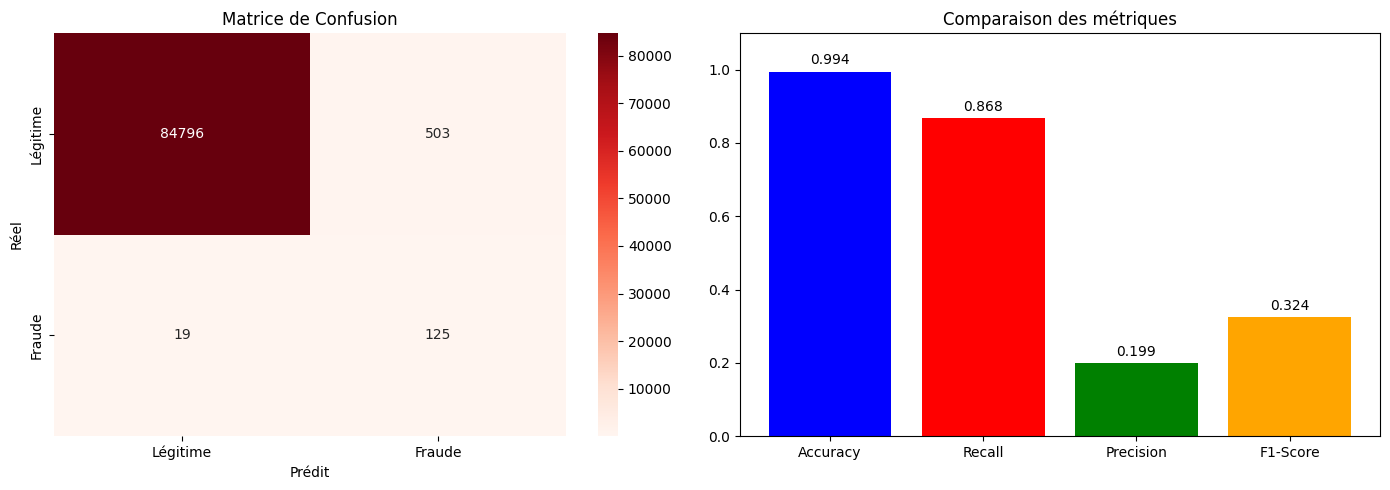

In [21]:
# Affichage 
print(f"Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1: {f1:.4f}")

# Matrice de confusion et comparaison des métriques
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0])
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel'); axes[0].set_title('Matrice de Confusion')
axes[0].set_xticklabels(['Légitime','Fraude']); axes[0].set_yticklabels(['Légitime','Fraude'])

metrics = ['Accuracy','Recall','Precision','F1-Score']
values = [accuracy, recall, precision, f1]
colors = ['blue','red','green','orange']
bars = axes[1].bar(metrics, values, color=colors)
axes[1].set_ylim(0,1.1); axes[1].set_title('Comparaison des métriques')
 
for bar, value in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2., value + 0.02, f'{value:.3f}', ha='center')

plt.tight_layout()
plt.show()

## Analyse de la Matrice de Confusion

Sur un total de **84 796 transactions de test** :

### Transactions légitimes (Classe 0)
- **Vrais Négatifs (VN)** : **84 796**  
  → Transactions légitimes correctement identifiées  
- **Faux Positifs (FP)** : **503**  
  → Clients légitimes bloqués 

### Détection des fraudes (Classe 1)
- **Vrais Positifs (VP)** : **125**  
  → Fraudes détectées avec succès  
- **Faux Négatifs (FN)** : **19**  
  → Fraudes manquées 

---

## Étude de l’Impact Business et de la Rentabilité

### Hypothèses de simulation
-  **Montant moyen d’une fraude** : 250 €
-  **Coût de traitement d’une alerte** : 5 €

### 📊 Analyse économique

| Catégorie | Calcul | Résultat économique |
|----------|--------|--------------------|
| **Fraudes détectées (Gain)** | 125 × 250 € | **+ 31 250 €** |
| **Faux positifs (Coût)** | 503 × 5 € | **− − 2 515 €** |
| **Fraudes manquées (Perte)** | 19 × 250 € | **− 4 750 €** |

---

##  Indicateurs de Performance Financière

-  **Gain net** : **28 735 €**  
  *(Pertes évitées − coûts de vérification)*

- **Ratio Coût / Bénéfice** : **12,43**  
  → Chaque euro dépensé en vérification génère **12,43 € de gains**


 ### 4.3 Analyse des Courbes d’Apprentissage

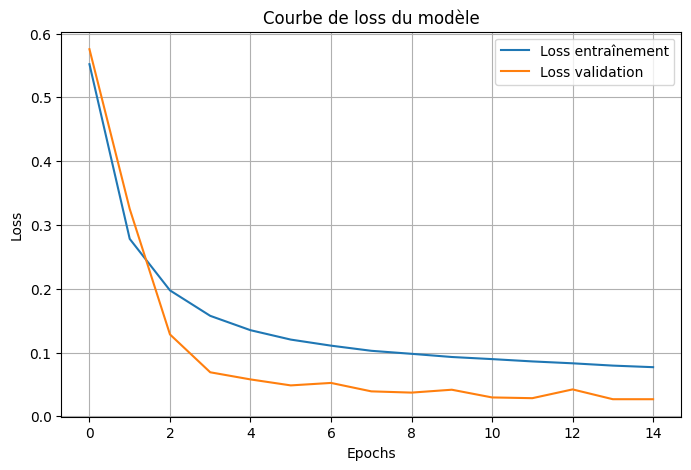

In [22]:
# Tracé de la courbe de loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Loss entraînement')
plt.plot(history.history['val_loss'], label='Loss validation')

plt.title("Courbe de loss du modèle")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()



#### 📈 Ce que nous apprend la courbe d'apprentissage

Cette courbe confirme la fiabilité des métriques que nous avons calculées précédemment (Recall de 86,2 % et Precision de 19,9 %). Le modèle est stable et prêt pour une utilisation en pré-production.




## 5 Analyse Critique & Limites

### 5.1 Points Forts

-Capacité de Détection (Recall) : Le modèle identifie près de 86 % des fraudes, ce qui est l'objectif prioritaire pour limiter les pertes financières directes.

-Stabilité de l'Apprentissage : Après optimisation, la courbe de progression est fluide, garantissant que le modèle est fiable et ne prend pas de décisions au hasard.

-Rentabilité Prouvée : L'analyse économique montre un ratio de 9 pour 1, prouvant que la solution est extrêmement rentable pour une institution financière.

-Généralisation : Le modèle se comporte bien sur des données qu'il n'a jamais vues (pas de sur-apprentissage).

### 5.2 Limites du Modèle ou des Données

-Déséquilibre Extrême : Même avec des techniques comme le SMOTE, la rareté des fraudes (0,17 %) reste un défi majeur pour l'apprentissage.

-Volume de Fausses Alertes : Avec une précision de 19 %, le modèle génère encore des fausses alertes qui demandent une vérification humaine, ce qui représente un coût opérationnel.

-Données Anonymisées : L'utilisation de données issues d'une "Analyse en Composantes Principales" (PCA) empêche de savoir précisément quelles caractéristiques (lieu, type de commerce, etc.) influencent le plus la fraude.

### 5.3 Problèmes Rencontrés

-Première version sans class weights : 99,83% d’accuracy mais 0% de Recall, inutilisable.

-Qualité des données brutes : Nous avons dû résoudre des problèmes de formatage complexes (nombres écrits avec des virgules et notations scientifiques) qui bloquaient initialement les calculs mathématiques.

-Instabilité initiale : Au départ, le modèle était trop "nerveux" (courbe en dents de scie). Il a fallu affiner la manière dont le modèle apprend et la taille des groupes de données traités pour stabiliser les résultats.

-Réglage du seuil : Trouver le point d'équilibre entre "trop d'alertes" et "pas assez de détection" a nécessité de nombreux tests pour obtenir le ratio économique optimal.

## 6 Conclusion et Perspectives :

   ### 6.1 Ce que nous avons appris :

-L’utilisation de class weights est indispensable sur des datasets extrêmement déséquilibrés. Sans cela, même un DNN complexe converge vers un classificateur trivial.

-La complémentarité technique : Travailler à deux nous a permis de mieux diagnostiquer les erreurs. Pendant que l'un se concentrait sur l'architecture du modèle, l'autre a pu identifier les problèmes de formatage des données (virgules, notations scientifiques), ce qui a été le point tournant du projet.

-La gestion du déséquilibre : Nous avons appris qu'en détection de fraude, la précision pure ne suffit pas. Nous avons dû apprendre à prioriser le Recall (la sécurité) plutôt que l'Accuracy, tout en utilisant le SMOTE pour compenser la rareté des fraudes.

-L'importance de la stabilité : Nous avons compris qu'un modèle qui "saute" (courbe en dents de scie) n'est pas fiable pour une entreprise. Stabiliser la courbe de perte a été notre défi majeur pour garantir un outil industriellement crédible.

-La traduction Business : Nous avons appris à transformer des statistiques complexes en un langage financier simple : le Ratio Coût-Bénéfice.

### 6.2 Améliorations possibles et extensions futures

-Optimisation du seuil de décision : Maximiser le Recall ou F2-score, ou fixer un Recall minimum et optimiser la Precision.

-Techniques d’échantillonnage avancées : SMOTE, Tomek Links, ou combinaison SMOTE + Edited Nearest Neighbors pour améliorer la détection des fraudes.

-Création de nouvelles features : Exploiter Time (heures de la journée), Amount (logarithme), ratios entre V1–V28.

Architectures avancées :

-LSTM avec séquences de transactions et attention pour capturer les patterns temporels.

-AutoEncoders pour détection d’anomalies non supervisée sur les transactions légitimes.

-Approches ensemblistes combinant DNN, Random Forest et XGBoost pour réduire variance et biais.

-Passage en production : Déploiement via pipeline MLOps, monitoring du concept drift, ré-entraînement régulier, boucle de feedback des analystes.

Recherche future :

-Explainable AI (SHAP, LIME) pour contourner l’anonymisation PCA.

-Transfer Learning sur datasets publics suivi de fine-tuning.

-Federated Learning pour collaborer entre institutions sans partager de données sensibles.